In [1]:
#importing dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")


In [2]:
#Loading  the datas
data = pd.read_csv("C:\\Users\\DELL\\Downloads\\PRCP-1020-HousePricePred\\Data\\data.csv")

In [3]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### EDA

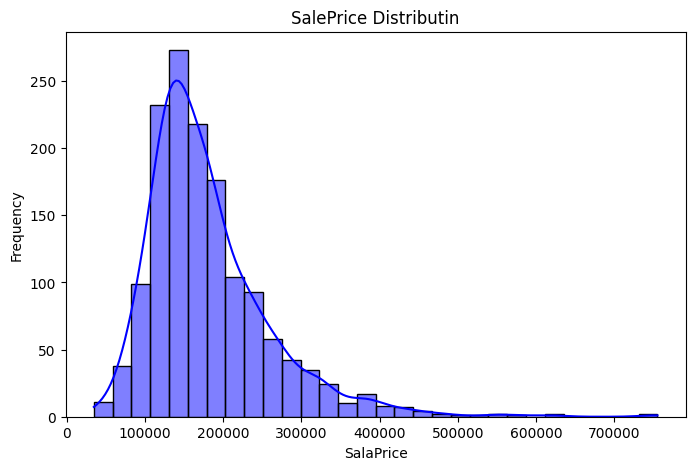

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data['SalePrice'],kde=True, color="Blue", bins=30)
plt.title("SalePrice Distributin")
plt.xlabel("SalaPrice")
plt.ylabel("Frequency")
plt.show()

In [7]:
data = data.select_dtypes(include=[float, int])

### Correlation heatmap

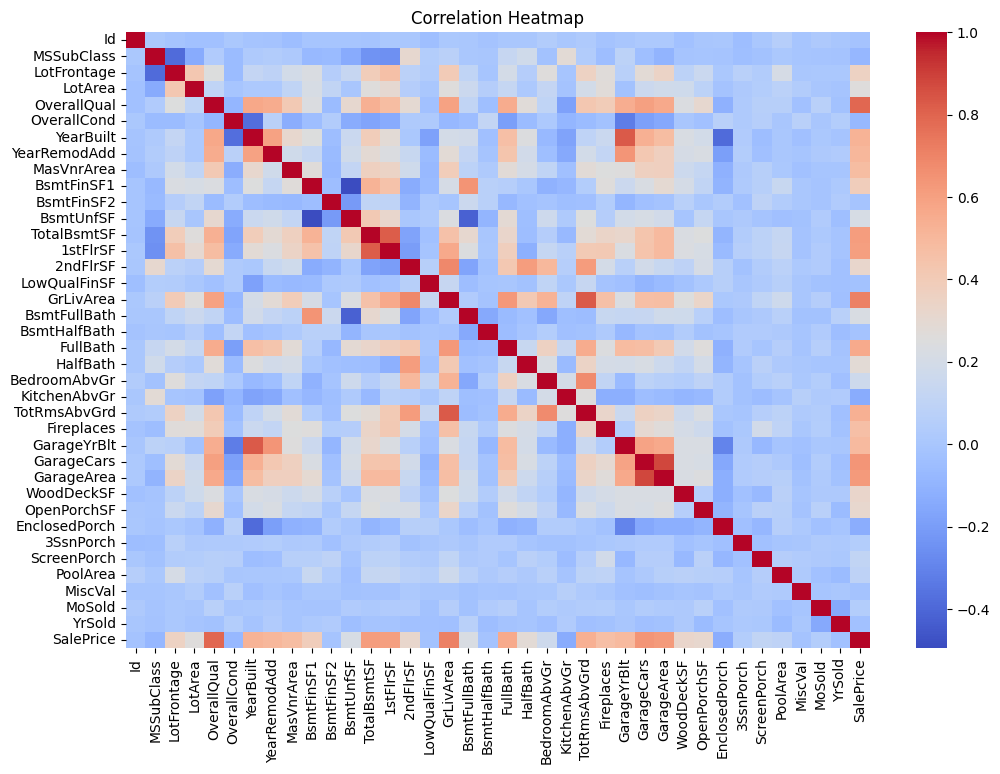

In [8]:
correlation_matrics = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrics, annot=False, cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

In [9]:
data.fillna(data.median(), inplace=True)

In [10]:
categorical_cols = data.select_dtypes(include=['object']).columns
data[categorical_cols] = data[categorical_cols].fillna("None")

In [11]:
data_encoded = pd.get_dummies(data, drop_first=True)
print(data_encoded.shape)

(1460, 38)


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [13]:
X = data_encoded.drop("SalePrice", axis=1)
y = data_encoded["SalePrice"]

### Feature importance

In [23]:
from sklearn.ensemble import ExtraTreesRegressor
selection = ExtraTreesRegressor()
selection.fit(X, y)

ExtraTreesRegressor()

In [24]:
print(selection.feature_importances_)

[0.0048226  0.00603202 0.00733694 0.01132515 0.33167992 0.00786179
 0.0441002  0.02669438 0.00683458 0.02349319 0.00213871 0.00430257
 0.03999638 0.03183203 0.01923255 0.00060978 0.07548449 0.00993229
 0.00269534 0.04103609 0.00819884 0.01016584 0.00332495 0.01576682
 0.0312468  0.01388137 0.15998619 0.03147474 0.00625873 0.00614461
 0.00191652 0.00161777 0.00275269 0.00209687 0.00043657 0.00410355
 0.00318615]


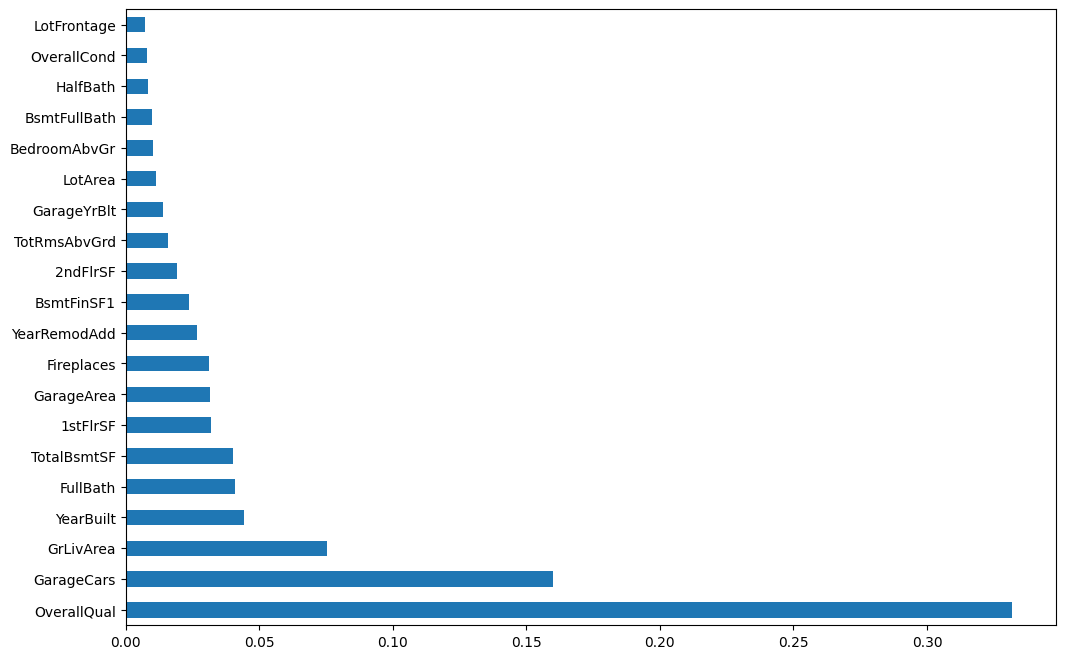

In [25]:
plt.figure(figsize = (12,8))
feat_importances = pd.Series(selection.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.show()

### Splitting The Data

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Accuracy Score

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
lr_clf = LinearRegression()

In [17]:
lr_clf.fit(X_train, y_train)
lr_clf.score(X_test, y_test)

0.8226775450640375

In [18]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [19]:
predictions = model.predict(X_test)
rmse = mean_squared_error(y_test, predictions, squared=False)
print(f"RMSE: {rmse}")

RMSE: 29159.325958926194


In [20]:
score_1 = metrics.r2_score(y_test, predictions)
print(score_1)


0.8891486140990713


### Refining the model

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error, r2_score

# Load your dataset
file_path = "C:\\Users\\DELL\\Downloads\\PRCP-1020-HousePricePred\\Data\\data.csv"
data = pd.read_csv("C:\\Users\\DELL\\Downloads\\PRCP-1020-HousePricePred\\Data\\data.csv")

# Add more features for refinement
selected_features = [
    'GrLivArea', 'OverallQual', 'GarageCars', 'TotalBsmtSF', 
    'YearBuilt', 'YearRemodAdd', 'FullBath', 'Fireplaces'
]
target = 'SalePrice'

# Drop rows with missing values in the selected features or target
data_refined = data.dropna(subset=selected_features + [target])

# Define X (features) and y (target)
X_refined = data_refined[selected_features]
y_refined = data_refined[target]

# Split the refined data into train and test sets
X_train_refined, X_test_refined, y_train_refined, y_test_refined = train_test_split(
    X_refined, y_refined, test_size=0.2, random_state=42
)

# Initialize Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)

# Define hyperparameter grid for tuning
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Grid search with cross-validation
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, scoring='r2', cv=5, n_jobs=-1)
grid_search.fit(X_train_refined, y_train_refined)

# Best model from grid search
best_model = grid_search.best_estimator_

# Predict on the test set with the refined model
y_pred_refined = best_model.predict(X_test_refined)

# Calculate refined MAPE and R2 score
mape_refined = mean_absolute_percentage_error(y_test_refined, y_pred_refined)
r2_refined = r2_score(y_test_refined, y_pred_refined)

print("Best Parameters:", grid_search.best_params_)
print("Refined MAPE:", mape_refined)
print("Refined R2:", r2_refined)


Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Refined MAPE: 0.11824273454057364
Refined R2: 0.9007489529314323


### Suggestions for the customer to buy the house

 Area Preferance:Specific neighborhoods or cities.


Price Range: Budget limits, including flexibility.


### Other Requirements

Type (Apartment, Villa, Independent House)

Size (e.g., 2BHK, 3BHK, square footage)

Amenities (e.g., garden, pool, parking, security)

Proximity (to schools, offices, public transport, etc.)